# Linear Regression Training Project: Ecommerce Clients

In this project we work with a dataset [available on Kaggle](https://www.kaggle.com/iyadavvaibhav/ecommerce-customer-device-usage/notebooks). The data includes information about customers of an e-commerce website, including the following:
- Avg. Session Length: Average session of in-store style advice sessions.
- Time on App: Average time spent on App in minutes
- Time on Website: Average time spent on Website in minutes
- Length of Membership: How many years the customer has been a member.

In this project, we suppose that the company is trying to decide whether to focus their efforts on their mobile app experience or their website. We are here to help them make a data-driven decision.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Getting the Data


**Note:** As mentioned before, the data comes from a test dataset freely [available on Kaggle](https://www.kaggle.com/iyadavvaibhav/ecommerce-customer-device-usage/notebooks). Note that this is a training set and the information does not correspond to real people.

In [2]:
customers = pd.read_csv('Ecommerce Customers.txt')

In [3]:
customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [5]:
customers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


## Exploratory Data Analysis

First we ask the following question: How are the client's time spent on each platform related to the amount that they spend per year? There doesn't seem to be much correlation between the time on the desktop website with the amount that clients spend per year. On the other side, the second graph shows that there seems to be a small correlation between the time spent on the app and the yearly spending. This is probably because these clients tend to spend less time browsing on the phone. Maybe the payment process is faster on the app or the calls-to-action are more successful there.

After analysing the pairplot, we see that there does seem to be one big positive correlation between two variables: the length of membership and the yearly expenditure. In the end we recrate this plot to visualise the regression line.

In [6]:
corr = customers.corr(numeric_only = True)
corr

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Avg. Session Length,1.000000,-0.027826,-0.034987,0.060247,0.355088
Time on App,-0.027826,1.000000,0.082388,0.029143,0.499328
Time on Website,-0.034987,0.082388,1.000000,-0.047582,-0.002641
Length of Membership,0.060247,0.029143,-0.047582,1.000000,0.809084
Yearly Amount Spent,0.355088,0.499328,-0.002641,0.809084,1.000000


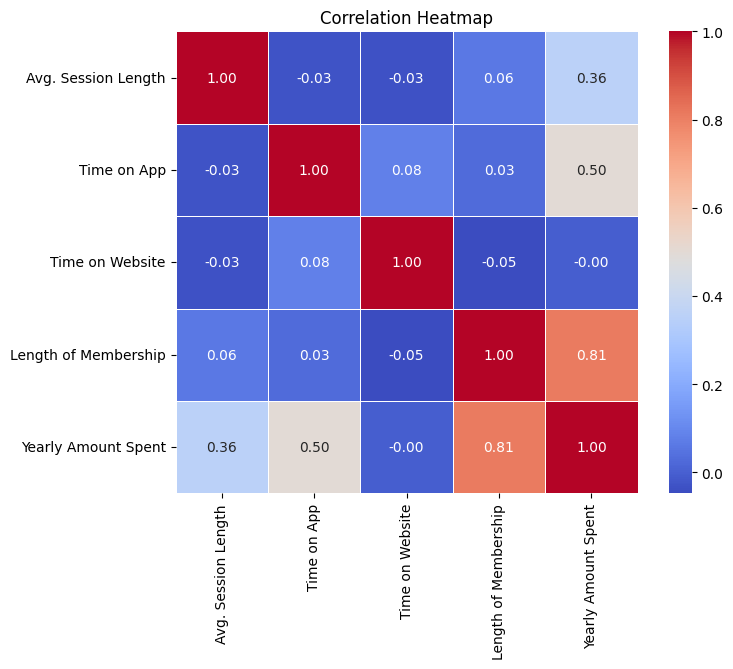

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap")

plt.show()

In [8]:
customers.drop(columns = ['Email', 'Address', 'Avatar', 'Time on Website'], axis = 1, inplace = True)

`Email`, `Address`, and `Avatar` were dropped because they are identifiers or non-numeric categorical features with **no predictive value**.
`Time on Website` was removed due to its **near-zero correlation** with Yearly Amount Spent, indicating **no meaningful** linear relationship.

In [9]:
# Separates features and target variable
x = customers.iloc[:, :-1].values 
y = customers.iloc[:, -1].values  

In [10]:
customers.head()

,Avg. Session Length,Time on App,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,4.082621,587.951054
1,31.926272,11.109461,2.664034,392.204933
2,33.000915,11.330278,4.104543,487.547505
3,34.305557,13.717514,3.120179,581.852344
4,33.330673,12.795189,4.446308,599.406092


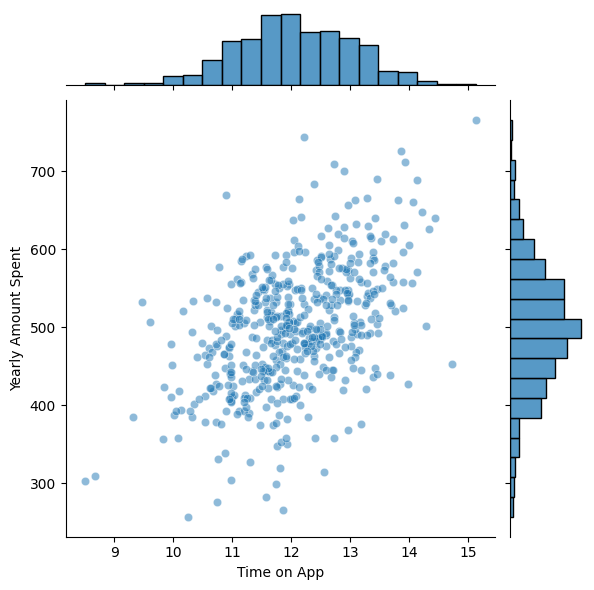

In [11]:
# Time on app vs Yearly amount spent(Shows joint relationship and distributions)
sns.jointplot(x='Time on App', y='Yearly Amount Spent', data=customers, alpha=0.5)
plt.show()

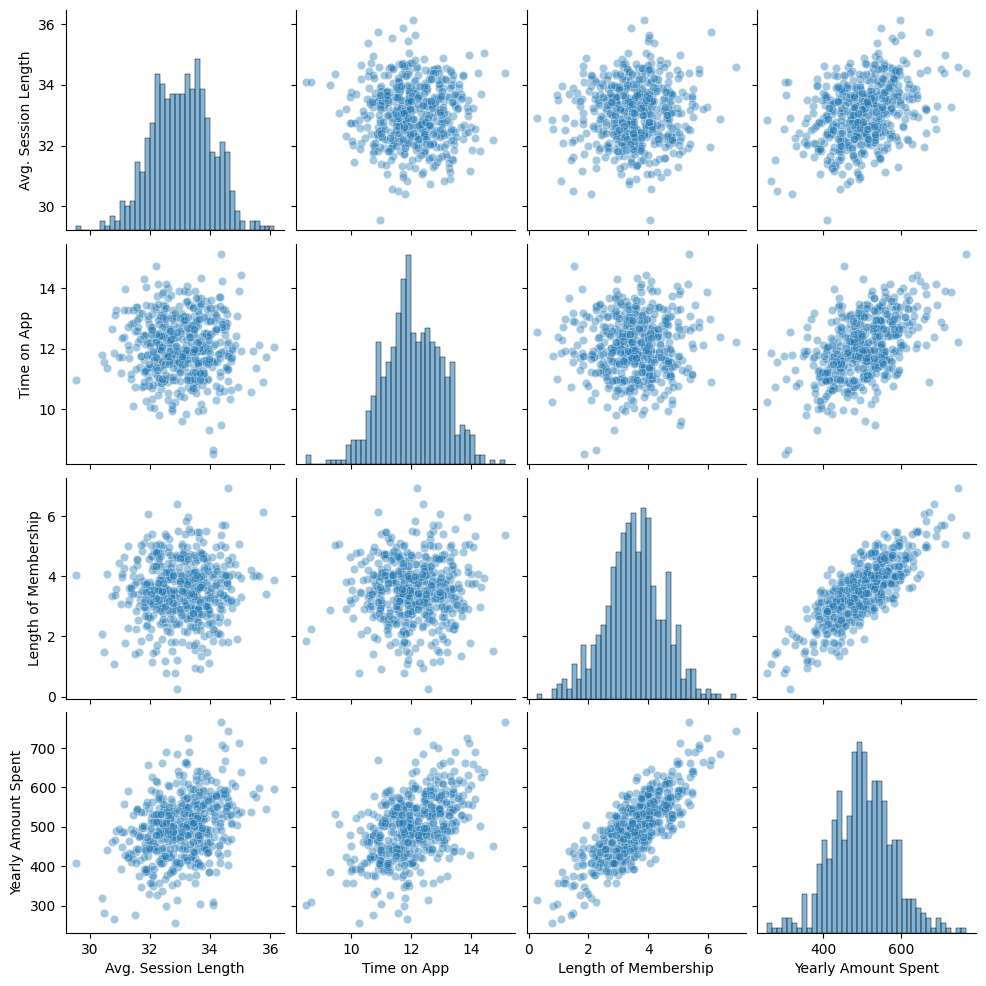

In [12]:
# Visualizes relationships and distributions between features
sns.pairplot(customers, 
             kind='scatter', 
             plot_kws={'alpha':0.4}, 
             diag_kws={'alpha':0.55, 'bins':40})

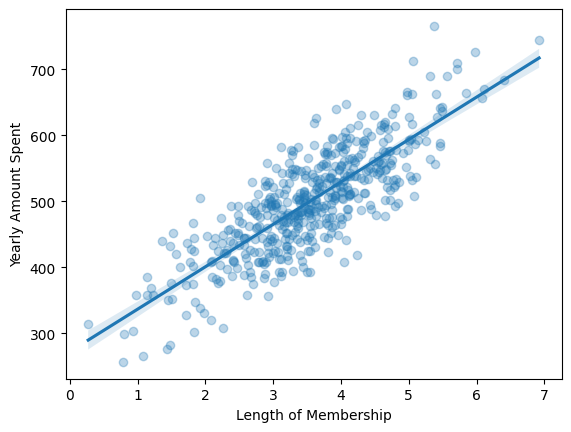

In [13]:
# length of membership vs Yearly amount spent(Shows linear relationship with trendline)
sns.regplot(x='Length of Membership', y='Yearly Amount Spent',
            data=customers, scatter_kws={'alpha':0.3})
plt.show()

## Splitting the data

x are the predictores, and y is the output. What we want to do is create a model that will take in the values in the X variable and predict y with a linear regression algorithm. We will use the SciKit Learn library to create the model.

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Avg. Session Length   500 non-null    float64
 1   Time on App           500 non-null    float64
 2   Length of Membership  500 non-null    float64
 3   Yearly Amount Spent   500 non-null    float64
dtypes: float64(4)
memory usage: 15.8 KB


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state = 101)

In [17]:
#Standardizes features using training data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

## Training the Model with multivariable regression using Scikit Learn

In this section, we create the model and feed the training data to it. This model will tell us which input has the biggest impact in the output (yearly expenditure). As the plots suggested, we find that the most important coefficient is that of the "Length of Membership" predictor, followed by the 'Time on App' and the 'Avg. Session Length'. The time on website does not seem to be an important factor to the amount a customer spends per year.

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
regression = LinearRegression(n_jobs = -1)

In [20]:
regression.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [21]:
# the coefficients
regression.coef_

array([26.04870628, 36.69255503, 60.19248611])

In [22]:
# the intercept
regression.intercept_

np.float64(498.7231164913069)

## Training the model with multivariable regression using OLS

Allows us to get more details about the moel

In [23]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,x_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.023
Model:                            OLS   Adj. R-squared (uncentered):              0.014
Method:                 Least Squares   F-statistic:                              2.673
Date:                Sun, 18 Jan 2026   Prob (F-statistic):                      0.0473
Time:                        12:37:29   Log-Likelihood:                         -2670.9
No. Observations:                 350   AIC:                                      5348.
Df Residuals:                     347   BIC:                                      5359.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            26.0487     26.844      0.970      0.333     -26.748      78.846
x2            36.6926     26.847      1.367      0.173     -16.110      89.495
x3            60.1925     26.803      2.246      0.025       7.476     112.909
==============================================================================
Omnibus:                        0.506   Durbin-Watson:                   0.001
Prob(Omnibus):                  0.776   Jarque-Bera (JB):                0.494
Skew:                          -0.091   Prob(JB):                        0.781
Kurtosis:                       2.972   Cond. No.                         1.08
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Predicting Test Data
Now that the model is trained, we should be able to use it to make our predictions and evaluate our model. The scatter plot below plots the actual y values to the model's predictions. The model seems to behave accurately.

In [24]:
predictions = regression.predict(x_test)

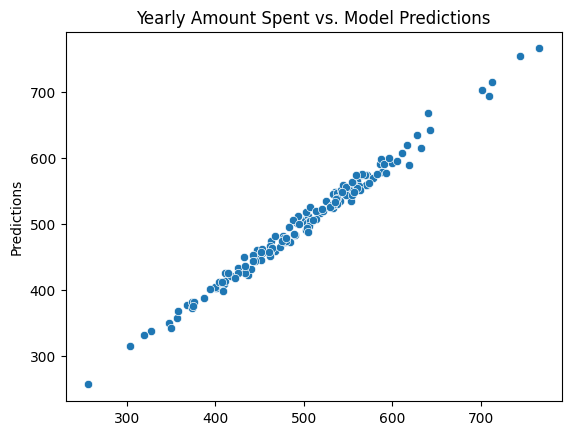

In [25]:
# Scatter plot of actual values of y vs predicted values.
sns.scatterplot(x = y_test, y = predictions)
plt.ylabel('Predictions')
plt.title('Yearly Amount Spent vs. Model Predictions')

plt.show()

## Evaluation of the model

In [26]:
from sklearn.metrics import r2_score
score = r2_score(y_test,predictions)
print(f"R-squared: {score:.4f}" )

R-squared: 0.9890


In [27]:
#adjusted R-squared

n = len(y_test)
p = x_test.shape[1]

adjusted_Rsquared = 1 - (1-score)*(n-1)/(n-p-1)
print(f"Adjusted R-squared {adjusted_Rsquared:.4f}")

Adjusted R-squared 0.9887


In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [29]:
print('Mean Absolute Error:', mean_absolute_error(y_test, predictions))
print('Mean Squared Error:', mean_squared_error(y_test, predictions))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error: 7.236949056091398
Mean Squared Error: 80.19544609397647
Root Mean Squared Error: 8.955191013818547


## Residuals
Distribution plot of the residuals of the model's predictions. They should be normally distributed.

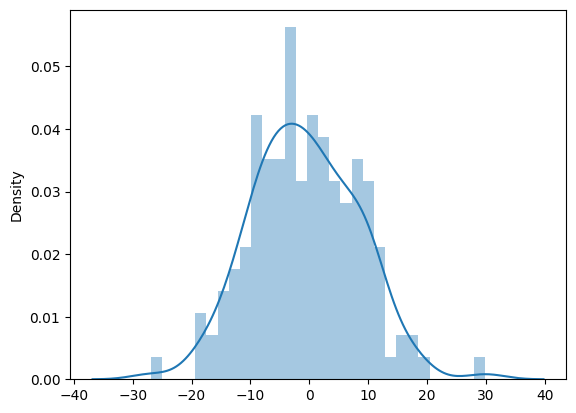

In [30]:
residuals = y_test-predictions
sns.distplot(residuals, bins=30)

plt.show()

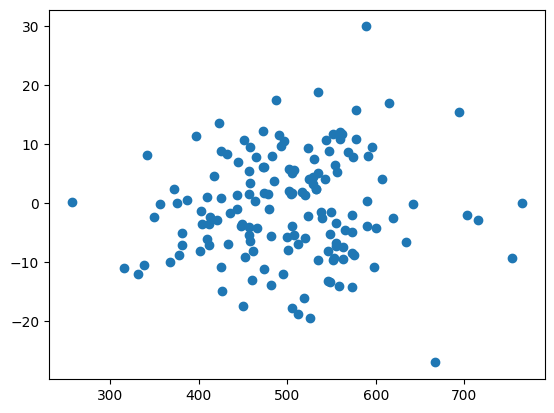

In [31]:
# Residuals should be randomly scattered around the zero line with no clear pattern.
plt.scatter(predictions, residuals)

plt.show()